In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zkskhurram/hantavirus-andes-virus-global-epidemiology")

print("Path to dataset files:", path)

100%|██████████| 106k/106k [00:00<00:00, 8.38MB/s]

Extracting files...
Path to dataset files: C:\Users\alexa\.cache\kagglehub\datasets\zkskhurram\hantavirus-andes-virus-global-epidemiology\versions\1


Ideas:

Classification:

Tree-Based Decisions, Maybe Random Forest
- Take all symptoms and determine likelihood of recovery

Clustering

Dimensionality Reduction:
- Symptoms?

1. Analyze hantavirus_clinical.csv
a. Clustering

In [3]:
# @title Set Up
import sys
assert sys.version_info >= (3, 7)
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)



In [2]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
le = LabelEncoder()

In [16]:
df = pd.read_csv('hantavirus_clinical.csv')

In [20]:

age_order = ['0-14','15-29','30-44','45-59','60+'] #youngest to oldest
severity_order = ['Mild','Moderate','Severe','Critical'] # least to most severe

oe = OrdinalEncoder(categories=[age_order,severity_order])
ordinal_encoded = oe.fit_transform(df[['age_group', 'severity']]).astype(int)


gender  = df['gender'].map({'Female': 0, 'Male': 1})
outcome = df['outcome'].map({'Recovered': 0, 'Deceased': 1})
syndrome = df['syndrome'].map({'HPS': 0, 'HFRS': 1})

country = le.fit_transform(df['country_iso3'])
virus = le.fit_transform(df['virus_strain'])


df_encoded = pd.DataFrame({
    'syndrome':     syndrome.values,
    'virus_strain': virus,
    'country_iso3': country,
    'age_group':    ordinal_encoded[:, 0],
    'gender':       gender.values,
    'severity':     ordinal_encoded[:, 1],
    'outcome':      outcome.values,
})
df_encoded

,syndrome,virus_strain,country_iso3,age_group,gender,severity,outcome
0,0,0,0,0,1,2,1
1,0,0,0,0,1,2,0
2,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0
4,0,0,0,0,1,2,1
...,...,...,...,...,...,...,...
7533,1,3,6,4,0,3,0
7534,1,3,6,4,0,0,0
7535,1,3,6,4,0,1,1
7536,1,3,6,4,0,1,0


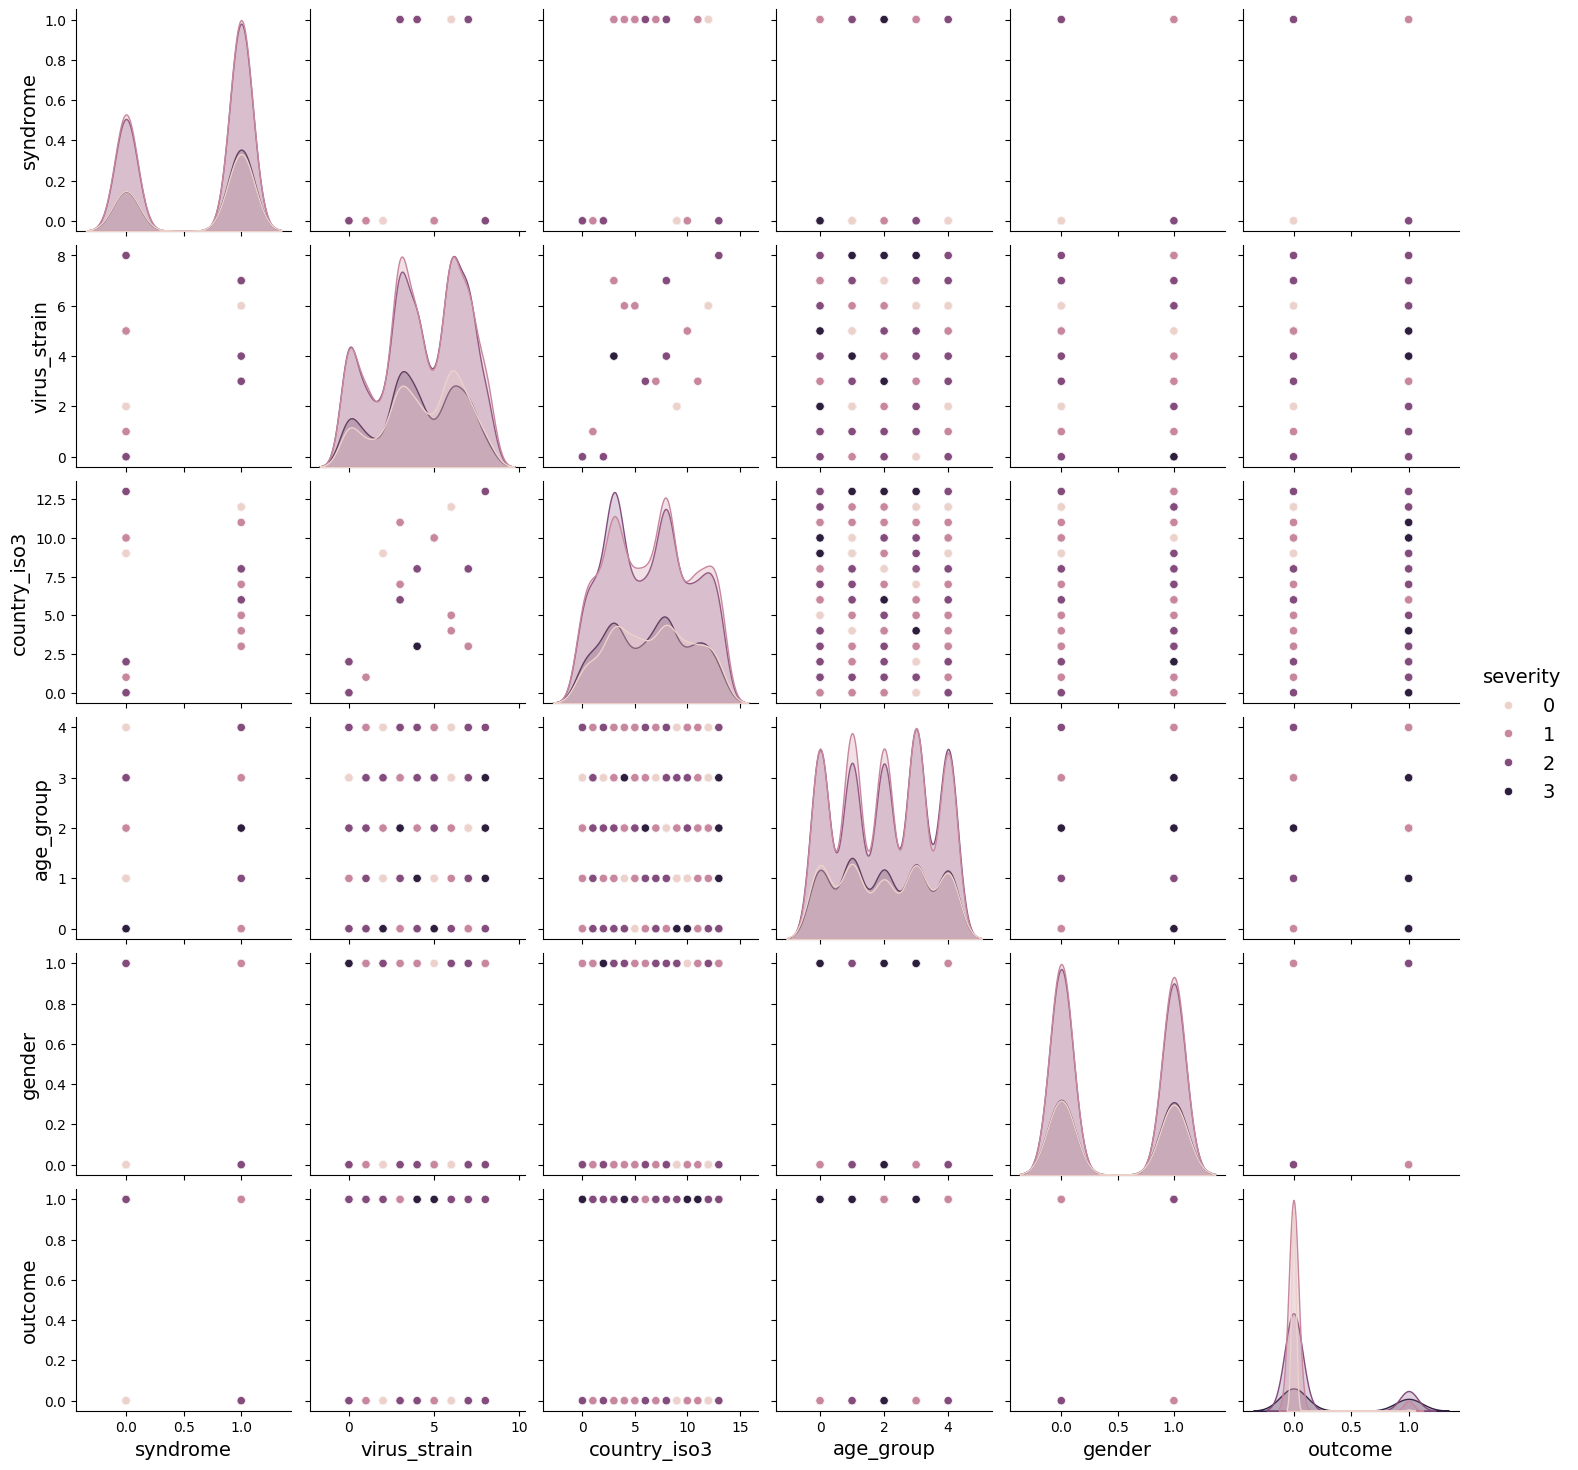

In [21]:
sns.pairplot(df_encoded, hue='severity')